In [1]:
###############################
# Notebook 08 – Residuenanalyse
# Projekt: Preisbewertung NL
###############################

import pandas as pd
import joblib
import statsmodels.api as sm


In [2]:
# Dateien laden
X_ml = pd.read_csv("../data_clean/X_ml.csv")
y_ml = pd.read_csv("../data_clean/y_ml.csv")
X_test = pd.read_csv("../data_clean/X_test.csv")
y_test = pd.read_csv("../data_clean/y_test.csv")

# Modelle laden
rf = joblib.load("../data_clean/rf_model.pkl")
model_ext = joblib.load("../data_clean/ols_model.pkl")

# OLS-Test
X_test_ols = sm.add_constant(X_test, has_constant='add')


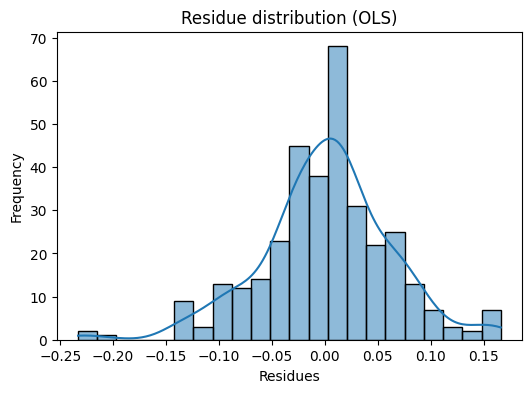

In [3]:
###########################################
# 8.1. Residuen berechnen und visualisieren
###########################################

import matplotlib.pyplot as plt
import seaborn as sns

# OLS-Vorhersagen
y_pred_ols = model_ext.predict(X_test_ols)

# Residuen berechnen
residuals = y_test.values.ravel() - y_pred_ols

plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Residue distribution (OLS)")
plt.xlabel("Residues")
plt.ylabel("Frequency")
plt.show()


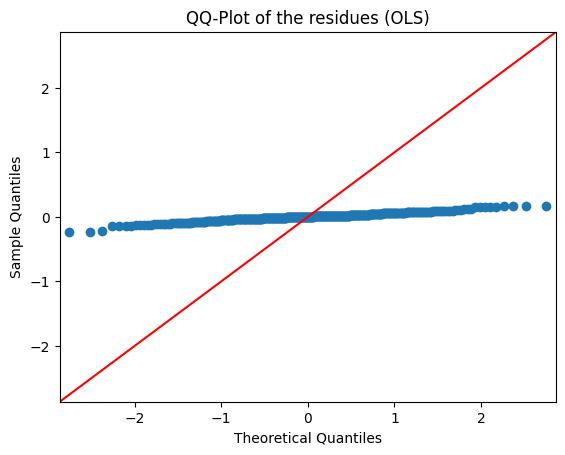

In [4]:
######################################
# 8.2. QQ‑Plot (Normalverteilungstest)
#####################################

sm.qqplot(residuals, line='45')
plt.title("QQ-Plot of the residues (OLS)")
plt.show()


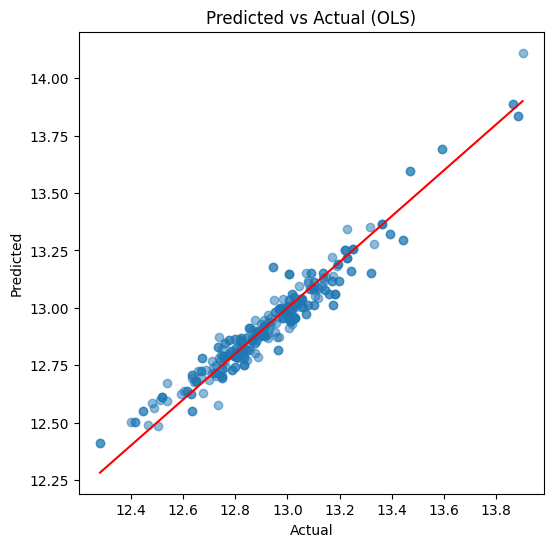

In [5]:
#################################
# 8.3. Predicted vs. Actual (OLS)
#################################

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_ols, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual (OLS)")
plt.show()


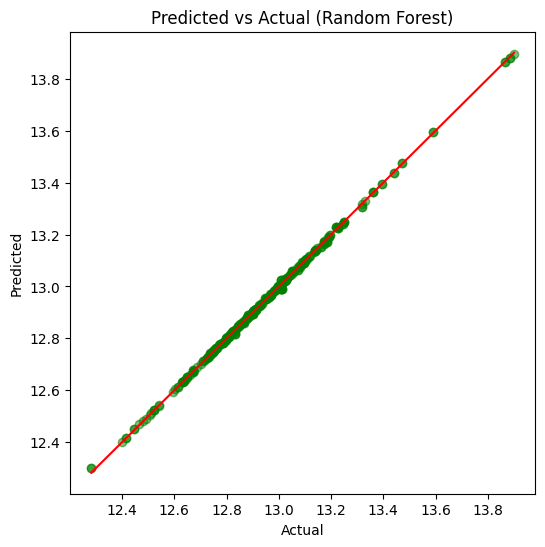

In [6]:
############################################
# 8.4. Predicted vs. Actual (Random-Forrest)
############################################

# RF-Vorhersagen
y_pred_rf = rf.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual (Random Forest)")
plt.show()


In [7]:
########################
# 8.5. Overfitting-Check
########################

from sklearn.metrics import r2_score

r2_train_rf = r2_score(y_ml, rf.predict(X_ml))
r2_test_rf = r2_score(y_test, y_pred_rf)

print("RF Train R²:", r2_train_rf)
print("RF Test R²:", r2_test_rf)

RF Train R²: 0.9997730988172627
RF Test R²: 0.999546042726652


In [8]:
####################################################################
# 8.6. Änderung Provinz Zeeland (statt Provinz Drenthe) als Referenz
####################################################################

# Dummy entfernen (Provinz Drenthe)
X_ml_zeeland = X_ml.drop(columns=["province_Zeeland"])

# OLS neu schätzen
X_ols_zeeland = sm.add_constant(X_ml_zeeland)
model_zeeland = sm.OLS(y_ml, X_ols_zeeland).fit()
print(model_zeeland.summary())

# Test‑Set anpassen
X_test_zeeland = X_test.drop(columns=["province_Zeeland"])
X_test_ols_zeeland = sm.add_constant(X_test_zeeland, has_constant='add')
y_pred_ols_zeeland = model_zeeland.predict(X_test_ols_zeeland)


                            OLS Regression Results                            
Dep. Variable:        log_price_total   R-squared:                       0.928
Model:                            OLS   Adj. R-squared:                  0.927
Method:                 Least Squares   F-statistic:                     898.9
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:17:36   Log-Likelihood:                 2438.9
No. Observations:                1690   AIC:                            -4828.
Df Residuals:                    1665   BIC:                            -4692.
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [9]:
#############################################
# 8.7. Änderung 'nicht_randstad' als Referenz
#############################################

# 1. Provinz-Dummies entfernen
cols_to_drop = [col for col in X_ml.columns if col.startswith("province_")]
X_ml_randstad = X_ml.drop(columns=cols_to_drop)

# 2. Randstad als Referenz setzen
# is_randstad = 1 → Randstad
# is_randstad = 0 → Nicht-Randstad
# Wir brauchen keinen zweiten Dummy
# Wir lassen is_randstad einfach drin

# 3. OLS schätzen
X_ols_randstad = sm.add_constant(X_ml_randstad)
model_randstad = sm.OLS(y_ml, X_ols_randstad).fit()
print(model_randstad.summary())


                            OLS Regression Results                            
Dep. Variable:        log_price_total   R-squared:                       0.920
Model:                            OLS   Adj. R-squared:                  0.919
Method:                 Least Squares   F-statistic:                     1284.
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:17:36   Log-Likelihood:                 2346.0
No. Observations:                1690   AIC:                            -4660.
Df Residuals:                    1674   BIC:                            -4573.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

province
Drenthe          12.817109
Flevoland        12.833812
Fryslân          12.757969
Gelderland       12.936375
Groningen        12.565526
Limburg          12.730430
Noord-Brabant    12.975934
Noord-Holland    13.117571
Overijssel       12.828890
Utrecht          13.077923
Zeeland          12.718705
Zuid-Holland     12.957163
Name: log_price_total, dtype: float64

count    8.422000e+03
mean     1.885613e-16
std      1.644174e-01
min     -6.379930e-01
25%     -9.761854e-02
50%     -2.391431e-03
75%      8.712416e-02
max      7.830282e-01
Name: price_deviation_from_province, dtype: float64

province
Drenthe          0.123969
Flevoland        0.082711
Fryslân          0.173087
Gelderland       0.122652
Groningen        0.140722
Limburg          0.139908
Noord-Brabant    0.121798
Noord-Holland    0.294799
Overijssel       0.090804
Utrecht          0.107115
Zeeland          0.146534
Zuid-Holland     0.172996
Name: price_deviation_from_province, dtype: float64



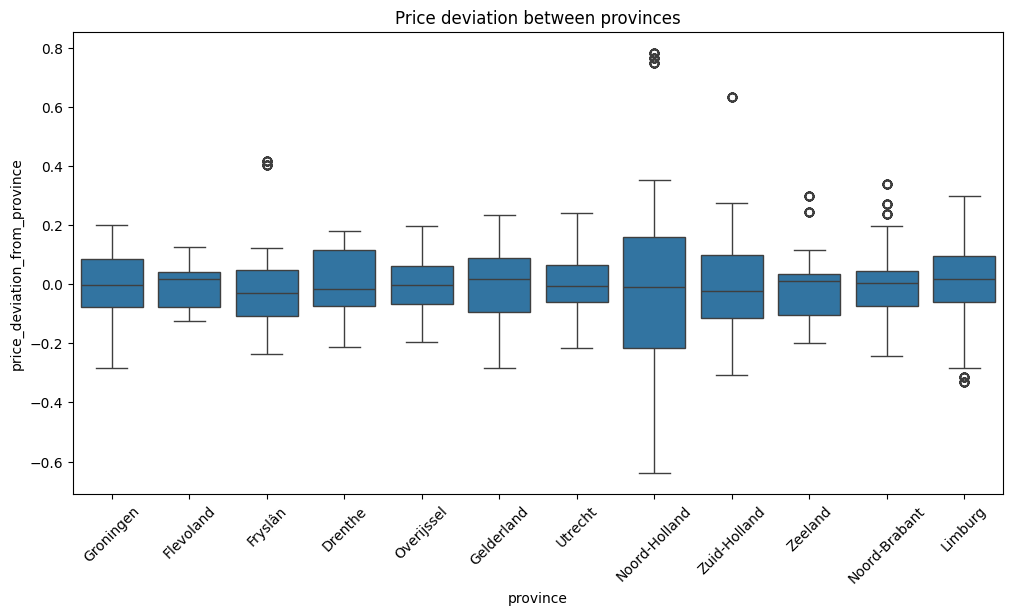

In [10]:
#########################################################################
# 8.8. Abweichungen realer Preise zwischen Provinzebene und Gemeindeebene
#########################################################################

import pandas as pd

# Laden der vorbereiteten Modelldaten
df = pd.read_csv("../data_clean/df_model_prepared.csv")

# Laden der Geodaten (mit Provinz)
df_geo = pd.read_csv("../data_clean/df_geo.csv")

# Merge über die Gemeinde
df = df.merge(df_geo[["municipality_code", "province"]], on="municipality_code", how="left")

# Provinz-Durchschnitt berechnen
province_means = df.groupby("province")["log_price_total"].mean()
print(province_means)
print()

# Abweichungen zwischen Provinz und Gemeinde brechnen
df["price_deviation_from_province"] = df.apply(
    lambda row: row["log_price_total"] - province_means[row["province"]],
    axis=1
)
print(df["price_deviation_from_province"].describe())
print()

# Heterogenität auf Provinzebene ermitteln
province_variation = df.groupby("province")["price_deviation_from_province"].std()
print(province_variation)
print()

# Boxplot der Abweichungen auf Provinzebene
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="province", y="price_deviation_from_province")
plt.xticks(rotation=45)
plt.title("Price deviation between provinces")
plt.show()


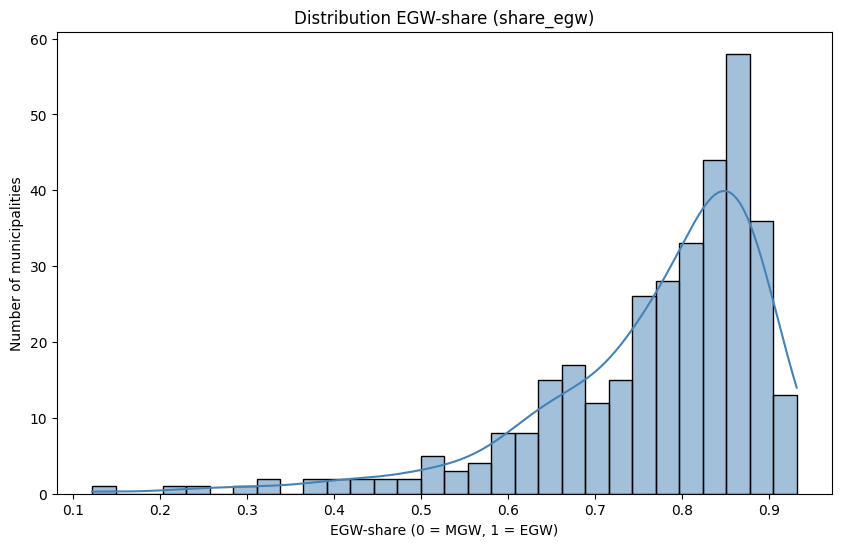

In [11]:
###################################################
# 8.9. Analyse der Differenzen zwischen EGW und MGW
###################################################

# EGW‑Verteilung pro Gemeinde

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Laden der Geodaten (mit Provinz)
df_geo = pd.read_csv("../data_clean/df_geo.csv")

# Merge über die Gemeinde
cols_to_drop = [col for col in df.columns if "share_egw" in col or "share_mgw" in col]
df = df.drop(columns=cols_to_drop)

df = df.merge(
    df_geo[["municipality_code", "share_egw", "share_mgw"]],
    on="municipality_code",
    how="left"
)
df_gemeenten = df.drop_duplicates(subset="municipality_code")

# Histogramm
plt.figure(figsize=(10,6))
sns.histplot(df_gemeenten["share_egw"], bins=30, kde=True, color="steelblue")
plt.title("Distribution EGW-share (share_egw)")
plt.xlabel("EGW-share (0 = MGW, 1 = EGW)")
plt.ylabel("Number of municipalities")
plt.show()


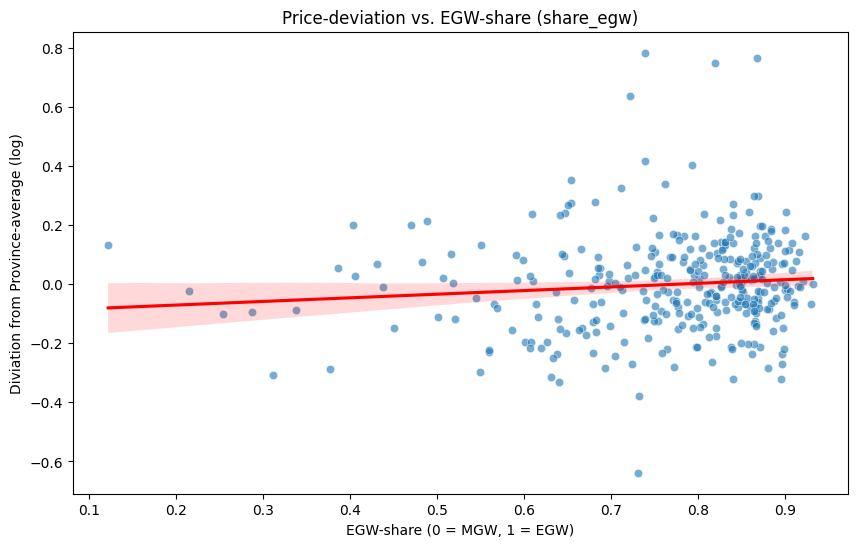

In [12]:
# EGW Preisabweichung

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_gemeenten,
    x="share_egw",
    y="price_deviation_from_province",
    alpha=0.6
)
sns.regplot(
    data=df_gemeenten,
    x="share_egw",
    y="price_deviation_from_province",
    scatter=False,
    color="red"
)
plt.title("Price-deviation vs. EGW-share (share_egw)")
plt.xlabel("EGW-share (0 = MGW, 1 = EGW)")
plt.ylabel("Diviation from Province-average (log)")
plt.show()


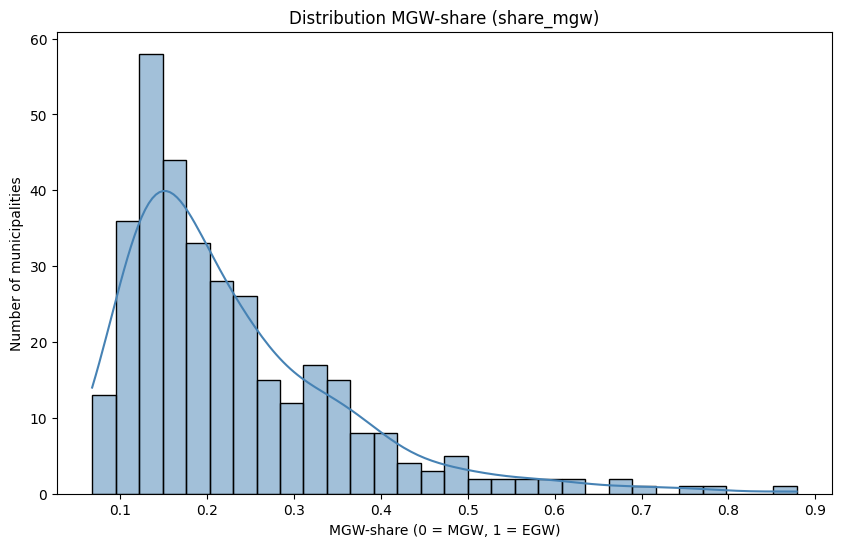

In [19]:
# MGW‑Verteilung pro Gemeinde

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Laden der Geodaten (mit Provinz)
df_geo = pd.read_csv("../data_clean/df_geo.csv")

# Merge über die Gemeinde
cols_to_drop = [col for col in df.columns if "share_mgw" in col or "share_egw" in col]
df = df.drop(columns=cols_to_drop)

df = df.merge(
    df_geo[["municipality_code", "share_mgw", "share_egw"]],
    on="municipality_code",
    how="left"
)
df_gemeenten = df.drop_duplicates(subset="municipality_code")

# Histogramm
plt.figure(figsize=(10,6))
sns.histplot(df_gemeenten["share_mgw"], bins=30, kde=True, color="steelblue")
plt.title("Distribution MGW-share (share_mgw)")
plt.xlabel("MGW-share (0 = MGW, 1 = EGW)")
plt.ylabel("Number of municipalities")
plt.show()


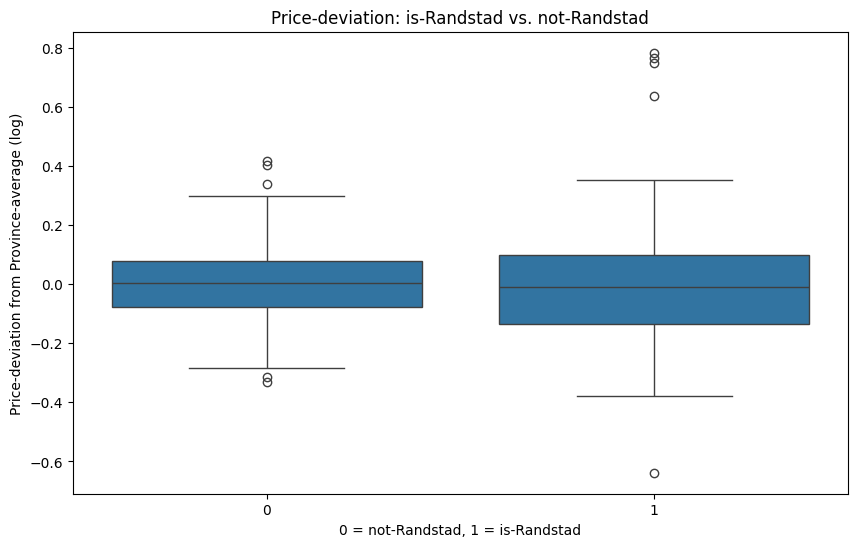

In [13]:
# Boxplot: Randstad vs. Nicht‑Randstad

plt.figure(figsize=(10,6))
sns.boxplot(
    data=df_gemeenten,
    x="is_randstad",
    y="price_deviation_from_province"
)
plt.title("Price-deviation: is-Randstad vs. not-Randstad")
plt.xlabel("0 = not-Randstad, 1 = is-Randstad")
plt.ylabel("Price-deviation from Province-average (log)")
plt.show()


C:\Users\sk\AppData\Local\Temp\ipykernel_8836\1943131419.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_gemeenten["type"] = df_gemeenten["share_egw"].apply(


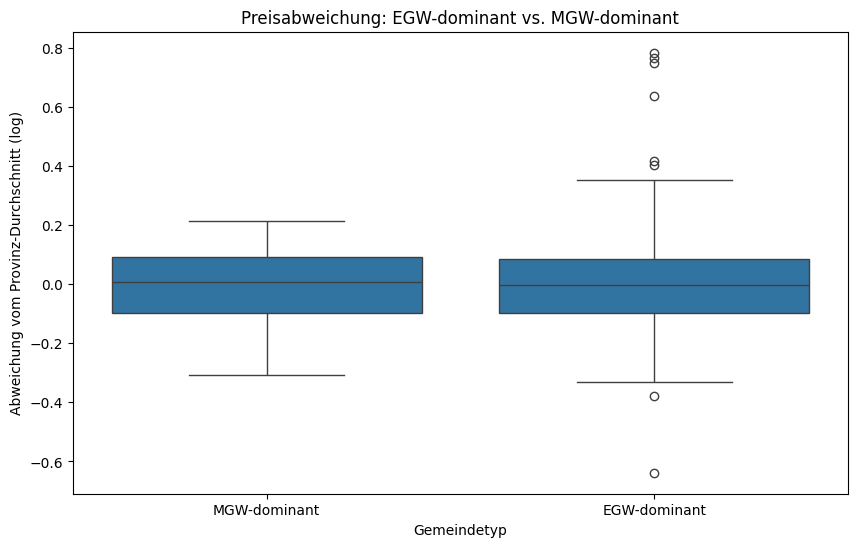

In [14]:
# EGW vs. MGW – Preisabweichungen getrennt darstellen

df_gemeenten["type"] = df_gemeenten["share_egw"].apply(
    lambda x: "EGW-dominant" if x > 0.5 else "MGW-dominant"
)

plt.figure(figsize=(10,6))
sns.boxplot(
    data=df_gemeenten,
    x="type",
    y="price_deviation_from_province"
)
plt.title("Preisabweichung: EGW-dominant vs. MGW-dominant")
plt.xlabel("Gemeindetyp")
plt.ylabel("Abweichung vom Provinz-Durchschnitt (log)")
plt.show()


<Figure size 1000x1000 with 0 Axes>

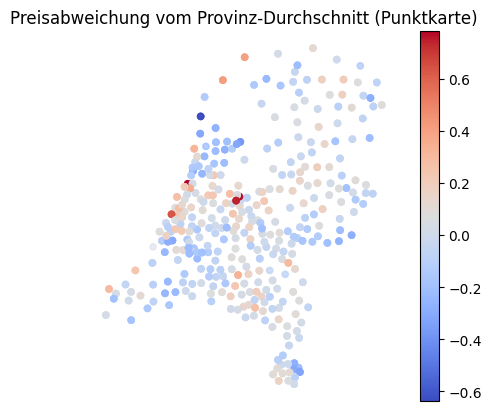

In [15]:
# Karte der Preisabweichungen

import geopandas as gpd
from shapely.geometry import Point

# Punkt-Geometrien erzeugen
df_geo["geometry"] = df_geo.apply(
    lambda row: Point(row["longitude"], row["latitude"]),
    axis=1
)

gdf = gpd.GeoDataFrame(df_geo, geometry="geometry", crs="EPSG:4326")


gdf = gdf.merge(
    df_gemeenten[["municipality_code", "price_deviation_from_province", "share_mgw"]],
    on="municipality_code",
    how="left"
)

plt.figure(figsize=(10,10))
gdf.plot(
    column="price_deviation_from_province",
    cmap="coolwarm",
    legend=True,
    markersize=20,
    alpha=0.5
)
plt.title("Preisabweichung vom Provinz-Durchschnitt (Punktkarte)")
plt.axis("off")
plt.show()


<Figure size 1000x1000 with 0 Axes>

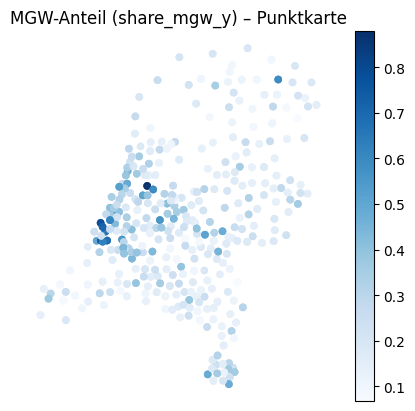

In [16]:
# MGW‑Cluster in der Randstad

import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. GeoDataFrame aus df_geo erzeugen (Punktgeometrien)
# ---------------------------------------------------------
df_geo["geometry"] = df_geo.apply(
    lambda row: Point(row["longitude"], row["latitude"]),
    axis=1
)

gdf = gpd.GeoDataFrame(df_geo, geometry="geometry", crs="EPSG:4326")

# ---------------------------------------------------------
# 2. Merge mit df_gemeenten (share_mgw + is_randstad)
#    Wichtig: df_gemeenten hat share_mgw, NICHT share_mgw_y
# ---------------------------------------------------------
gdf = gdf.merge(
    df_gemeenten[["municipality_code", "share_mgw", "is_randstad"]],
    on="municipality_code",
    how="left"
)

# ---------------------------------------------------------
# 3. MGW-Anteil als Punktkarte plotten
#    Wichtig: nach dem Merge heißt die Spalte share_mgw_y
# ---------------------------------------------------------
plt.figure(figsize=(10,10))
gdf.plot(
    column="share_mgw_y",
    cmap="Blues",
    legend=True,
    markersize=20,
    alpha=0.5
)
plt.title("MGW-Anteil (share_mgw_y) – Punktkarte")
plt.axis("off")
plt.show()


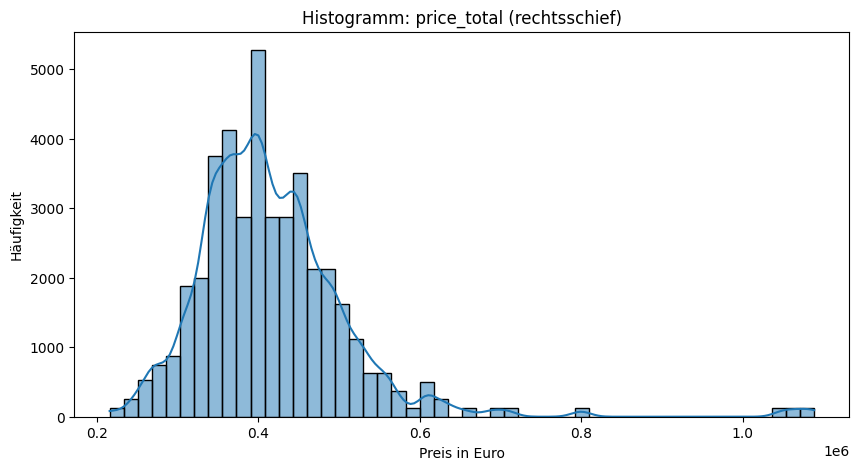

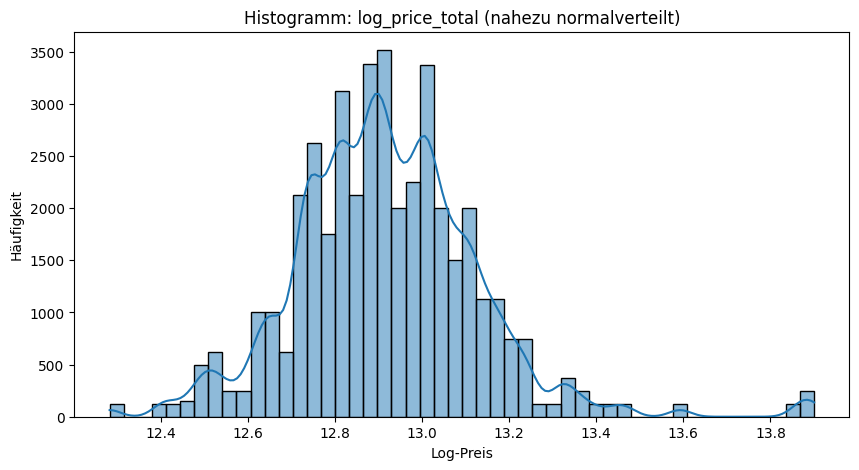

In [17]:
###########################################################
# 8.10. EXKURS: Vergleich price_totaal vs. log_price_totaal
###########################################################

# Histogramm 'price_totaal'

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(df["price_total"], bins=50, kde=True)
plt.title("Histogramm: price_total (rechtsschief)")
plt.xlabel("Preis in Euro")
plt.ylabel("Häufigkeit")
plt.show()

# Histogramm 'log_price_totaal'

plt.figure(figsize=(10,5))
sns.histplot(df["log_price_total"], bins=50, kde=True)
plt.title("Histogramm: log_price_total (nahezu normalverteilt)")
plt.xlabel("Log-Preis")
plt.ylabel("Häufigkeit")
plt.show()
